# HW1 – ADALINE


## 作業說明
-本作業依據課本第 44 頁 ADALINE 程式架構

-參考第 77 頁之亂數產生方法，自行建立兩群二維資料

-並呈現如課本第 47 頁之訓練誤差與分類結果



In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)


## 1) 亂數產生兩群資料

本實驗使用亂數方式產生兩群二維資料，
其中一群標記為 +1，另一群標記為 −1。
資料點依常態分布產生，
以確保資料具有隨機性與可重現性（設定 random seed）。


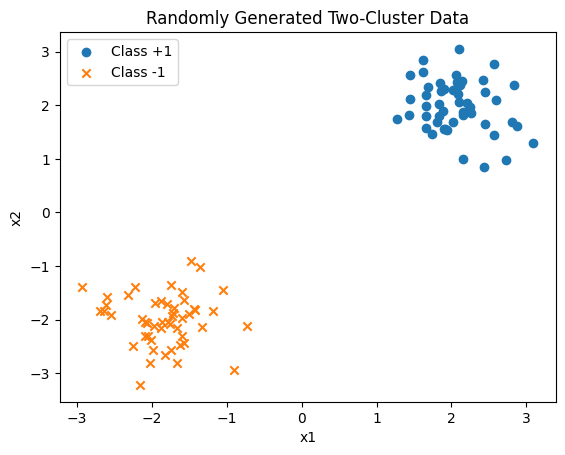

In [2]:
# Cluster sizes
n_per_class = 50

# Class +1 (center near (2, 2))
X_pos = np.random.normal(loc=2.0, scale=0.5, size=(n_per_class, 2))

# Class -1 (center near (-2, -2))
X_neg = np.random.normal(loc=-2.0, scale=0.5, size=(n_per_class, 2))

# Combine
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(n_per_class), -1 * np.ones(n_per_class)))

# Quick look at data
plt.figure()
plt.scatter(X_pos[:, 0], X_pos[:, 1], marker='o', label='Class +1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], marker='x', label='Class -1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Randomly Generated Two-Cluster Data')
plt.legend()
plt.show()


## 2)ADALINE 模型訓練

本實驗採用 ADALINE模型，
使用梯度下降法進行權重更新，
並以平方誤差作為學習目標函數。

訓練過程中紀錄每一個 epoch 的誤差值，
以觀察模型是否隨訓練次數逐漸收斂。  


In [6]:
class AdalineGD:
    """ADALINE classifier (Gradient Descent)."""

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = float(eta)
        self.n_iter = int(n_iter)
        self.random_state = int(random_state)

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for _ in range(self.n_iter):
            net = self.net_input(X)
            output = self.activation(net)  # identity
            errors = (y - output)

            # weight update
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()

            # cost (SSE / 2) averaged by number of samples
            cost = (errors ** 2).sum() / (2.0 * X.shape[0])
            self.cost_.append(cost)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        return X

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 3) 實驗結果與分析


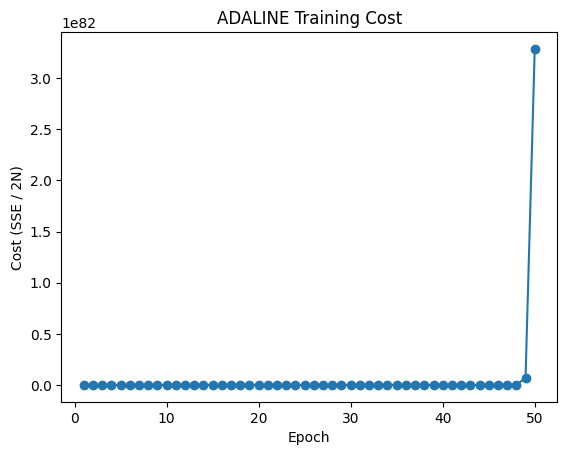

In [7]:
ada = AdalineGD(eta=0.01, n_iter=50, random_state=1)
ada.fit(X, y)

plt.figure()
plt.plot(range(1, len(ada.cost_) + 1), ada.cost_, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Cost (SSE / 2N)')
plt.title('ADALINE Training Cost')
plt.show()


## 4) 結果與決策邊界


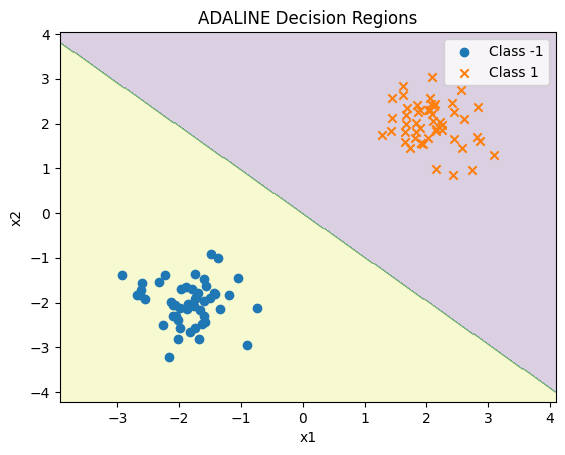

In [5]:
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # setup marker generator and color map (use default matplotlib cycle; avoid manual colors)
    markers = ('o', 'x')
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    grid = np.array([xx1.ravel(), xx2.ravel()]).T
    Z = classifier.predict(grid)
    Z = Z.reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            marker=markers[idx],
            label=f'Class {int(cl)}'
        )

plt.figure()
plot_decision_regions(X, y, classifier=ada)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('ADALINE Decision Regions')
plt.legend()
plt.show()
